<a href="https://colab.research.google.com/github/PriyanshuJVM/7th-sem-final-project/blob/main/brain_modle_xyz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brain Tumor MRI Classification Project

This notebook implements a brain tumor classification model using a Kaggle dataset. It covers the following steps:

1.  **Setup Kaggle API**: Install the Kaggle client and configure API credentials.
2.  **Download Dataset**: Obtain the specified brain tumor MRI dataset from Kaggle.
3.  **Data Preprocessing**: Load images, split data, and prepare generators for model input.
4.  **Model Building**: Define and compile a Convolutional Neural Network (CNN) model using a pre-trained Xception base.
5.  **Model Training**: Train the model on the prepared training data.
6.  **Performance Visualization**: Plot training and validation metrics.
7.  **Evaluation and Testing**: Evaluate the model's performance on unseen test data and visualize predictions.

### 1. Install the Kaggle API client

In [7]:
# Install the Kaggle API client
!pip install kaggle

### 2. Upload your Kaggle API key

To use the Kaggle API, you need to authenticate. Follow these steps to get your `kaggle.json` file:

1. Go to Kaggle.com and log in.
2. Click on your profile picture in the top right corner and select "My Account".
3. Scroll down to the "API" section and click "Create New API Token" to download `kaggle.json`.

Once you have the `kaggle.json` file, upload it to your Colab environment. You can do this by clicking the folder icon on the left sidebar, then selecting the 'Files' tab, and clicking the 'Upload to session storage' icon. **Make sure you upload it to the root directory of your Colab session (e.g., `/content/kaggle.json`).**

After uploading, run the following code to move it to the correct directory and set the appropriate permissions.

In [8]:
import os

# Create the .kaggle directory if it doesn't exist
!mkdir -p ~/.kaggle

# Move the uploaded kaggle.json file to the .kaggle directory
# Make sure you've uploaded kaggle.json to /content/kaggle.json first
!mv kaggle.json ~/.kaggle/

# Set permissions (this is important for security)
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API key configured.")

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle API key configured.


### 3. Download and Unzip the Dataset

We will download the 'Brain Tumor MRI Dataset' by `masoudnickparvar` from Kaggle and then unzip it. The dataset identifier is `masoudnickparvar/brain-tumor-mri-dataset`.

In [9]:
# Download the dataset
# Ensure you have uploaded kaggle.json before running this cell
!kaggle datasets download masoudnickparvar/brain-tumor-mri-dataset

# Unzip the dataset
# The dataset typically unzips into a folder named 'brain-tumor-mri-dataset'
!unzip -q brain-tumor-mri-dataset.zip -d brain_tumor_dataset

print("Dataset downloaded and unzipped into 'brain_tumor_dataset' directory.")

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:00<00:00, 192MB/s]

Dataset downloaded and unzipped into 'brain_tumor_dataset' directory.


In [10]:
# Verify the contents of the unzipped directory
print("Contents of the 'brain_tumor_dataset' directory:")
!ls -F brain_tumor_dataset/

print("\nContents of the Training directory:")
!ls -F brain_tumor_dataset/Training/

print("\nContents of the Testing directory:")
!ls -F brain_tumor_dataset/Testing/


Contents of the 'brain_tumor_dataset' directory:
Testing/  Training/

Contents of the Training directory:
glioma/  meningioma/  notumor/	pituitary/

Contents of the Testing directory:
glioma/  meningioma/  notumor/	pituitary/


### 4. Data Loading and Preprocessing

This section loads the images into dataframes, splits the data into training, validation, and testing sets, and sets up `ImageDataGenerator` for augmentation and batching.

In [11]:
import os
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import warnings
warnings.filterwarnings("ignore")

# Define paths to the dataset
# Adjust these paths if the dataset was unzipped into a different location
DATASET_BASE_PATH = 'brain_tumor_dataset'
TRAIN_DIR = os.path.join(DATASET_BASE_PATH, 'Training')
TEST_DIR = os.path.join(DATASET_BASE_PATH, 'Testing')

# Function to create a DataFrame from image paths and labels
def create_df(data_dir):
    filepaths = []
    labels = []
    for label_folder in os.listdir(data_dir):
        label_path = os.path.join(data_dir, label_folder)
        if os.path.isdir(label_path):
            for image_file in os.listdir(label_path):
                filepaths.append(os.path.join(label_path, image_file))
                labels.append(label_folder)
    return pd.DataFrame({'filepaths': filepaths, 'labels': labels})

# Create dataframes for training and testing data
tr_df = create_df(TRAIN_DIR)
ts_df = create_df(TEST_DIR)

print(f"Training DataFrame shape: {tr_df.shape}")
print(f"Testing DataFrame shape: {ts_df.shape}")

display(tr_df.head())
display(ts_df.head())

Training DataFrame shape: (5600, 2)
Testing DataFrame shape: (1600, 2)


,filepaths,labels
0,brain_tumor_dataset/Training/meningioma/Tr-me_...,meningioma
1,brain_tumor_dataset/Training/meningioma/Tr-me_...,meningioma
2,brain_tumor_dataset/Training/meningioma/Tr-aug...,meningioma
3,brain_tumor_dataset/Training/meningioma/Tr-me_...,meningioma
4,brain_tumor_dataset/Training/meningioma/Tr-me_...,meningioma


,filepaths,labels
0,brain_tumor_dataset/Testing/meningioma/Te-aug-...,meningioma
1,brain_tumor_dataset/Testing/meningioma/Te-me_2...,meningioma
2,brain_tumor_dataset/Testing/meningioma/Te-me_2...,meningioma
3,brain_tumor_dataset/Testing/meningioma/Te-me_2...,meningioma
4,brain_tumor_dataset/Testing/meningioma/Te-me_1...,meningioma


In [12]:
# Split the testing data into validation and test sets
# We'll use 50% for validation and 50% for testing from the original 'Testing' set
valid_df, ts_df = train_test_split(ts_df, train_size=0.5, random_state=42, stratify=ts_df['labels'])

print(f"Validation DataFrame shape: {valid_df.shape}")
print(f"Test DataFrame shape: {ts_df.shape}")

Validation DataFrame shape: (800, 2)
Test DataFrame shape: (800, 2)


In [13]:
# Data preprocessing and augmentation with ImageDataGenerator
batch_size = 32
img_size = (299, 299) # Xception model input size

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Only rescaling for validation and test (no augmentation)
validation_test_datagen = ImageDataGenerator(rescale=1./255)

# Create generators
tr_gen = train_datagen.flow_from_dataframe(
    tr_df,
    x_col='filepaths',
    y_col='labels',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

valid_gen = validation_test_datagen.flow_from_dataframe(
    valid_df,
    x_col='filepaths',
    y_col='labels',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

ts_gen = validation_test_datagen.flow_from_dataframe(
    ts_df,
    x_col='filepaths',
    y_col='labels',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

class_dict = tr_gen.class_indices
print(f"Class dictionary: {class_dict}")

Found 5600 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
Class dictionary: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


### 5. Building the Deep Learning Model

We will build a Convolutional Neural Network (CNN) using a pre-trained Xception model as a base for feature extraction, followed by custom dense layers for classification.

In [14]:
img_shape = (299, 299, 3) # Xception input shape
num_classes = len(tr_gen.class_indices)

# Load the Xception model with pre-trained ImageNet weights
base_model = tf.keras.applications.Xception(
    include_top=False, # Do not include the fully-connected layer at the top
    weights='imagenet',
    input_shape=img_shape,
    pooling='max' # Global max pooling after the convolutional layers
)

# Freeze the base model layers to prevent their weights from being updated during training
base_model.trainable = False

# Create the custom model on top of the base model
model = Sequential([
    base_model,
    Flatten(), # Flatten the output of the base model
    Dropout(rate=0.3),
    Dense(128, activation='relu'),
    Dropout(rate=0.25),
    Dense(num_classes, activation='softmax') # Output layer with softmax for multi-class classification
])

# Compile the model
model.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)

model.summary()

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 2048)           │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,124,268 (80.58 MB)

 Trainable params: 262,788 (1.00 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

### 6. Model Training

Train the model using the prepared image data generators.

In [15]:
epochs = 20 # You can adjust the number of epochs
hist = model.fit(
    tr_gen,
    epochs=epochs,
    validation_data=valid_gen,
    shuffle=False # Shuffle is handled by the generator
)

print("Model training complete.")

Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 195s 882ms/step - accuracy: 0.6814 - loss: 0.8568 - precision: 0.7319 - recall: 0.6248 - val_accuracy: 0.7850 - val_loss: 0.5993 - val_precision: 0.8179 - val_recall: 0.7300
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 140s 801ms/step - accuracy: 0.7918 - loss: 0.5417 - precision: 0.8307 - recall: 0.7554 - val_accuracy: 0.8150 - val_loss: 0.5239 - val_precision: 0.8525 - val_recall: 0.7875
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 141s 800ms/step - accuracy: 0.8266 - loss: 0.4717 - precision: 0.8530 - recall: 0.7945 - val_accuracy: 0.8200 - val_loss: 0.5075 - val_precision: 0.8577 - val_recall: 0.7912
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 140s 798ms/step - accuracy: 0.8363 - loss: 0.4354 - precision: 0.8615 - recall: 0.8086 - val_accuracy: 0.8512 - val_loss: 0.4628 - val_precision: 0.8720 - val_recall: 0.8263
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 140s 802ms/step - accuracy: 0.8548 - loss: 0.3981 - precision: 0.8789 - recall: 0.8291 - val_accuracy: 0

### 7. Visualize Model Performance

Plot the training and validation loss, accuracy, precision, and recall over epochs to assess model performance.

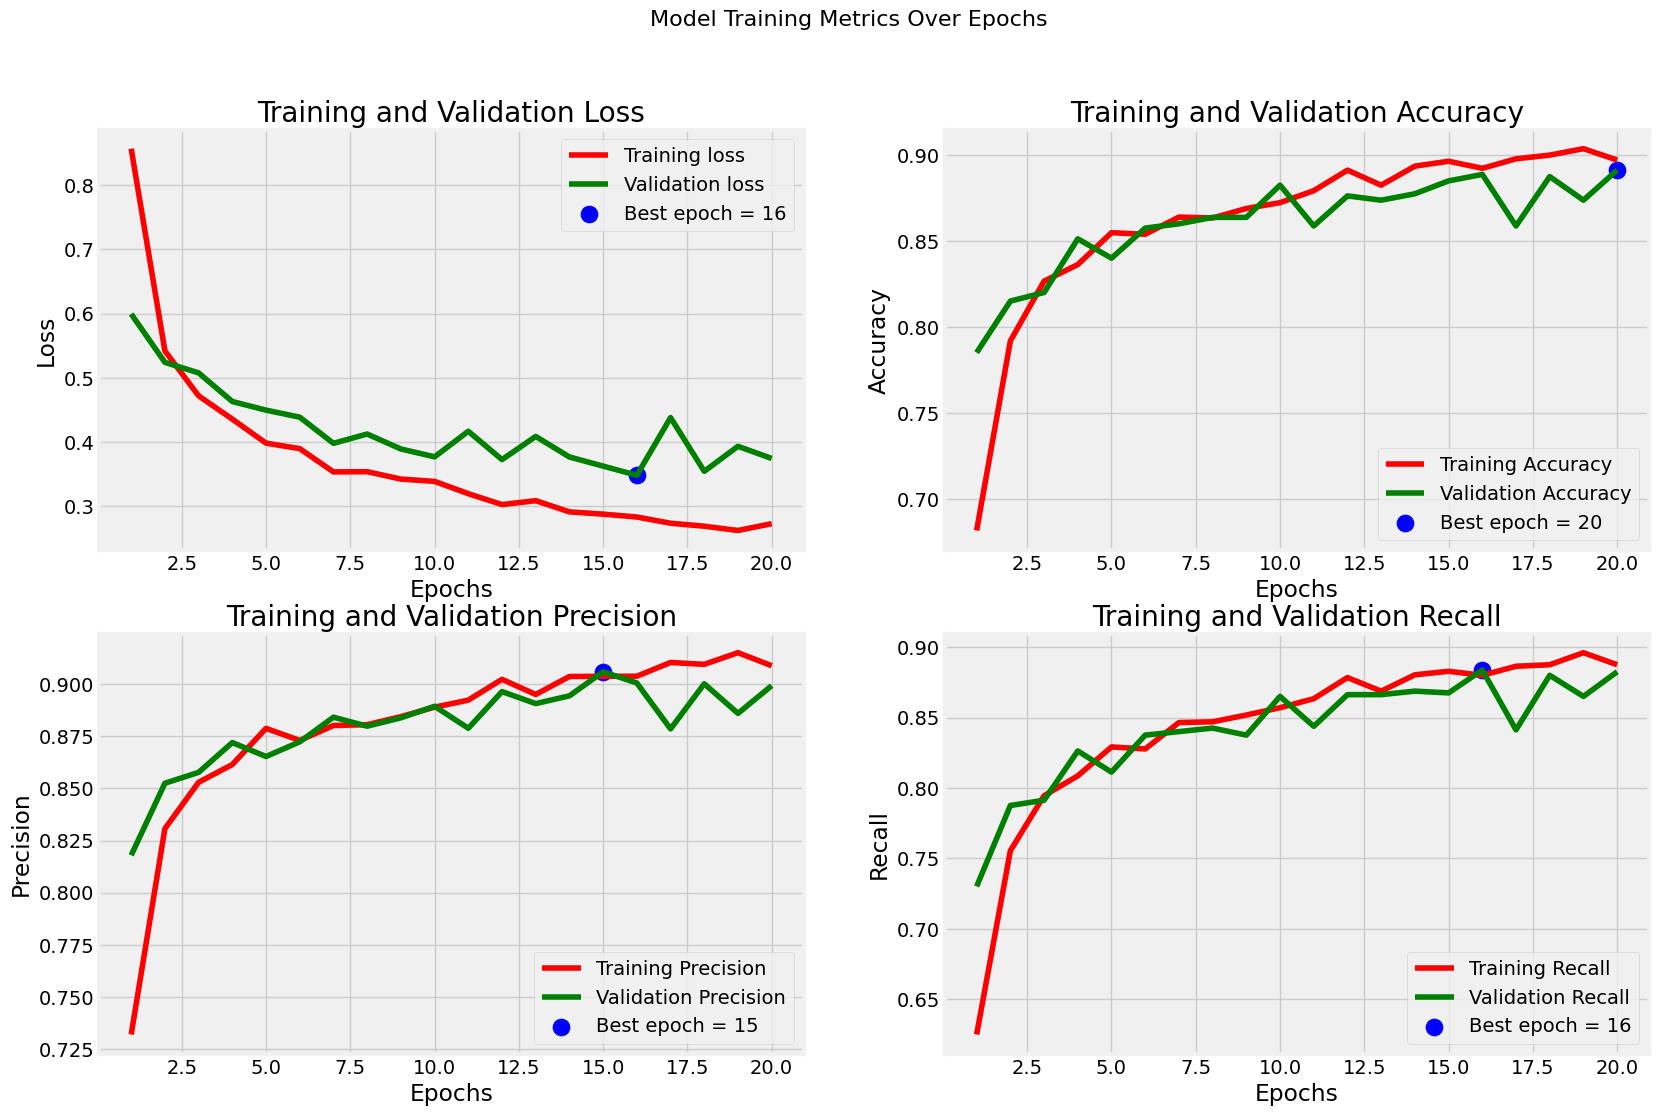

In [16]:
tr_acc = hist.history['accuracy']
tr_loss = hist.history['loss']
tr_per = hist.history['precision']
tr_recall = hist.history['recall']

val_acc = hist.history['val_accuracy']
val_loss = hist.history['val_loss']
val_per = hist.history['val_precision']
val_recall = hist.history['val_recall']

# Find the best epoch based on validation loss
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]

# Find the best epoch based on validation accuracy
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]

# Find the best epoch based on validation precision
index_precision = np.argmax(val_per)
per_highest = val_per[index_precision]

# Find the best epoch based on validation recall
index_recall = np.argmax(val_recall)
recall_highest = val_recall[index_recall]

Epochs = [i + 1 for i in range(len(tr_acc))]
loss_label = f'Best epoch = {str(index_loss + 1)}'
acc_label = f'Best epoch = {str(index_acc + 1)}'
per_label = f'Best epoch = {str(index_precision + 1)}'
recall_label = f'Best epoch = {str(index_recall + 1)}'

plt.figure(figsize=(20, 12))
plt.style.use('fivethirtyeight')

plt.subplot(2, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label='Training loss')
plt.plot(Epochs, val_loss, 'g', label='Validation loss')
plt.scatter(index_loss + 1, val_lowest, s=150, c='blue', label=loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label='Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label='Validation Accuracy')
plt.scatter(index_acc + 1, acc_highest, s=150, c='blue', label=acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(Epochs, tr_per, 'r', label='Training Precision')
plt.plot(Epochs, val_per, 'g', label='Validation Precision')
plt.scatter(index_precision + 1, per_highest, s=150, c='blue', label=per_label)
plt.title('Training and Validation Precision')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(Epochs, tr_recall, 'r', label='Training Recall')
plt.plot(Epochs, val_recall, 'g', label='Validation Recall')
plt.scatter(index_recall + 1, recall_highest, s=150, c='blue', label=recall_label)
plt.title('Training and Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

plt.suptitle('Model Training Metrics Over Epochs', fontsize=16)
plt.show()

### 8. Testing and Evaluation

Evaluate the trained model on the test dataset and visualize the confusion matrix and classification report.

Evaluating model performance...
175/175 ━━━━━━━━━━━━━━━━━━━━ 137s 785ms/step - accuracy: 0.9398 - loss: 0.1786 - precision: 0.9468 - recall: 0.9309
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 336ms/step - accuracy: 0.8913 - loss: 0.3742 - precision: 0.8994 - recall: 0.8825
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 353ms/step - accuracy: 0.8562 - loss: 0.4606 - precision: 0.8673 - recall: 0.8500

Train Loss: 0.1786
Train Accuracy: 93.98%
Train Precision: 0.9468
Train Recall: 0.9309

Validation Loss: 0.3742
Validation Accuracy: 89.13%
Validation Precision: 0.8994
Validation Recall: 0.8825

Test Loss: 0.4606
Test Accuracy: 85.62%
Test Precision: 0.8673
Test Recall: 0.8500

Generating predictions on the test set...
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 315ms/step


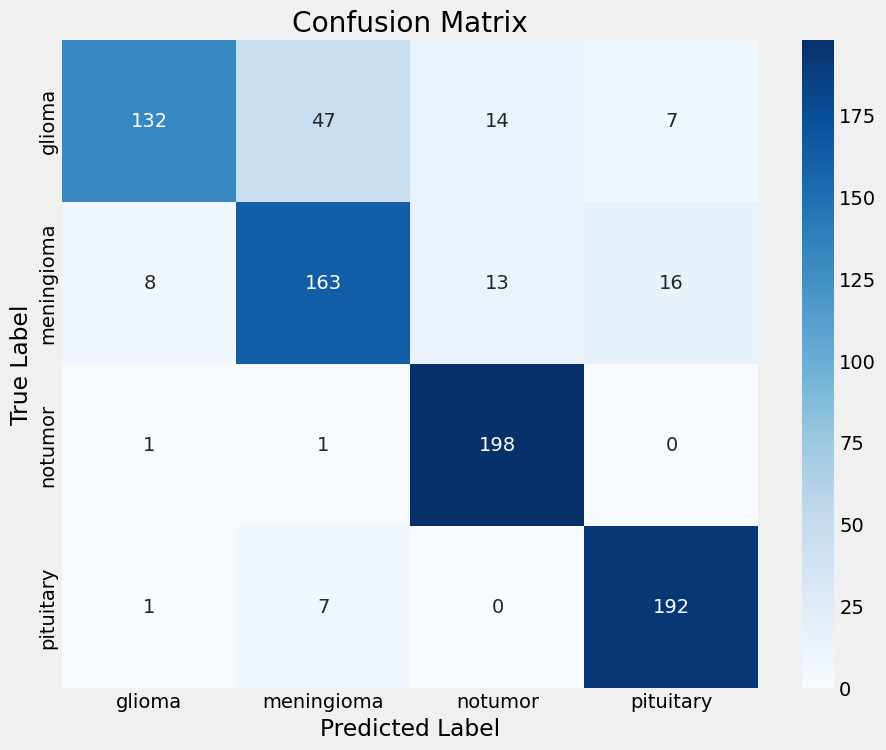


Classification Report:

              precision    recall  f1-score   support

      glioma       0.93      0.66      0.77       200
  meningioma       0.75      0.81      0.78       200
     notumor       0.88      0.99      0.93       200
   pituitary       0.89      0.96      0.93       200

    accuracy                           0.86       800
   macro avg       0.86      0.86      0.85       800
weighted avg       0.86      0.86      0.85       800



In [17]:
# Evaluate the model on training, validation, and test sets
print("Evaluating model performance...")
train_score = model.evaluate(tr_gen, verbose=1)
valid_score = model.evaluate(valid_gen, verbose=1)
test_score = model.evaluate(ts_gen, verbose=1)

print(f"\nTrain Loss: {train_score[0]:.4f}")
print(f"Train Accuracy: {train_score[1]*100:.2f}%")
print(f"Train Precision: {train_score[2]:.4f}")
print(f"Train Recall: {train_score[3]:.4f}\n")

print(f"Validation Loss: {valid_score[0]:.4f}")
print(f"Validation Accuracy: {valid_score[1]*100:.2f}%")
print(f"Validation Precision: {valid_score[2]:.4f}")
print(f"Validation Recall: {valid_score[3]:.4f}\n")

print(f"Test Loss: {test_score[0]:.4f}")
print(f"Test Accuracy: {test_score[1]*100:.2f}%")
print(f"Test Precision: {test_score[2]:.4f}")
print(f"Test Recall: {test_score[3]:.4f}\n")

# Make predictions on the test set
print("Generating predictions on the test set...")
preds = model.predict(ts_gen)
y_pred = np.argmax(preds, axis=1)
y_true = ts_gen.classes

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Get class labels from the generator
labels = list(ts_gen.class_indices.keys())

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Generate classification report
clr = classification_report(y_true, y_pred, target_names=labels)
print("\nClassification Report:\n")
print(clr)

### 9. Make Predictions on Sample Images

Define a function to load an image, preprocess it, and predict its class using the trained model. Then, demonstrate it with example images from the test set.

1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step

Predicting for image: brain_tumor_dataset/Testing/glioma/Te-gl_80.jpg
Predicted Class: glioma
Probabilities: [9.9980605e-01 1.6419528e-04 2.6298518e-05 3.4204920e-06]


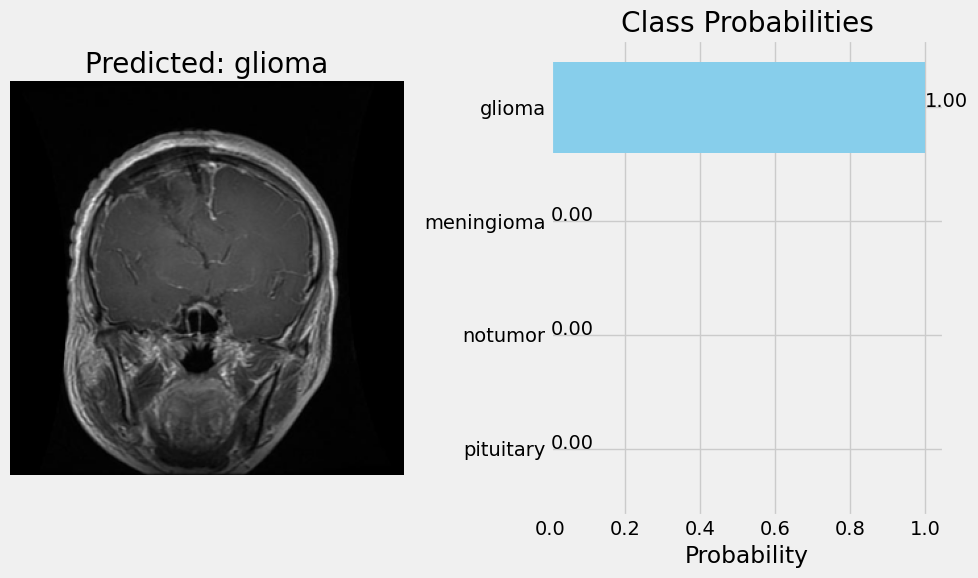

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

Predicting for image: brain_tumor_dataset/Testing/meningioma/Te-aug-me_87.jpg
Predicted Class: meningioma
Probabilities: [2.1801971e-02 8.3241904e-01 2.1649264e-04 1.4556241e-01]


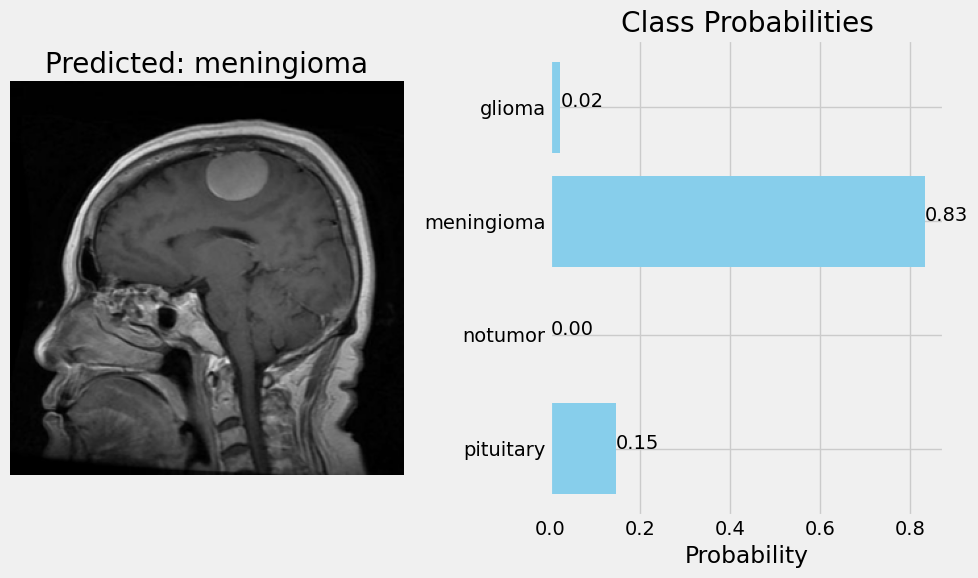

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

Predicting for image: brain_tumor_dataset/Testing/notumor/Te-no_125.jpg
Predicted Class: notumor
Probabilities: [4.1874904e-05 4.6739410e-06 9.9995339e-01 4.1944990e-08]


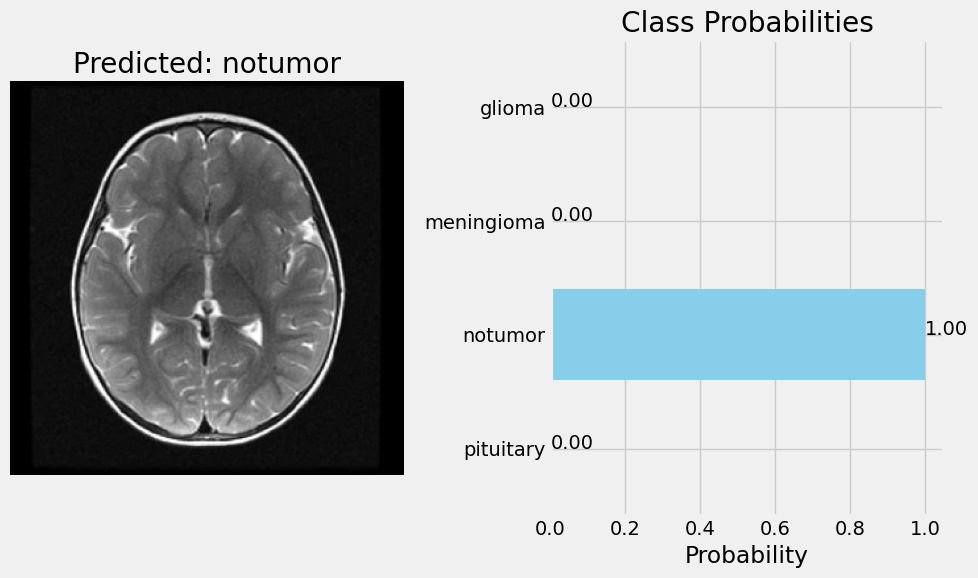

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

Predicting for image: brain_tumor_dataset/Testing/pituitary/Te-pi_286.jpg
Predicted Class: pituitary
Probabilities: [1.4107184e-03 6.9749214e-02 1.7879903e-04 9.2866123e-01]


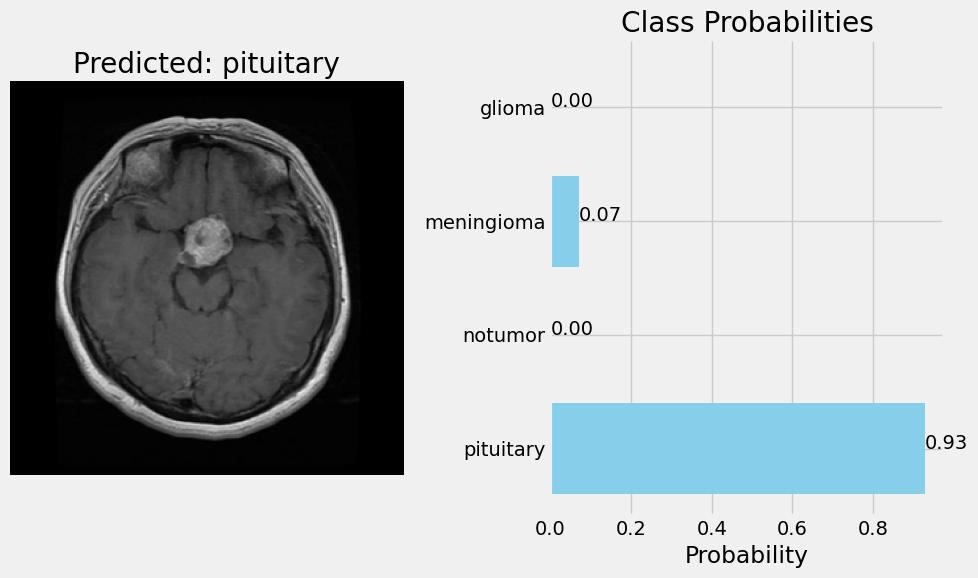

In [20]:
def predict_image_class(img_path, model, class_dict, img_size=(299, 299)):
    labels = list(class_dict.keys())

    # Load and preprocess the image
    img = Image.open(img_path).resize(img_size)
    # Convert image to RGB to match model's expected input shape (299, 299, 3)
    img = img.convert('RGB')
    img_array = np.asarray(img)
    img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
    img_array = img_array / 255.0 # Rescale to 0-1

    # Make prediction
    predictions = model.predict(img_array)
    probs = predictions[0] # Get probabilities for each class
    predicted_class_idx = np.argmax(probs)
    predicted_class_label = labels[predicted_class_idx]

    print(f"\nPredicting for image: {img_path}")
    print(f"Predicted Class: {predicted_class_label}")
    print(f"Probabilities: {probs}")

    # Display image and probabilities
    plt.figure(figsize=(10, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class_label}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    y_pos = np.arange(len(labels))
    plt.barh(y_pos, probs, align='center', color='skyblue')
    plt.yticks(y_pos, labels)
    plt.xlabel('Probability')
    plt.title('Class Probabilities')
    plt.gca().invert_yaxis() # Highest probability at the top
    for index, value in enumerate(probs):
        plt.text(value, index, f'{value:.2f}')
    plt.tight_layout()
    plt.show()

# Get a few sample image paths from the test set
# Assuming the dataset structure is 'brain_tumor_dataset/Testing/<class_name>/<image_name>.jpg'

# Example paths (adjust if the actual paths vary after unzipping)
# You might need to manually check the `brain_tumor_dataset/Testing` directory
# for exact image file names if these default examples don't exist.

sample_images = [
    os.path.join(TEST_DIR, 'glioma', os.listdir(os.path.join(TEST_DIR, 'glioma'))[0]),
    os.path.join(TEST_DIR, 'meningioma', os.listdir(os.path.join(TEST_DIR, 'meningioma'))[0]),
    os.path.join(TEST_DIR, 'notumor', os.listdir(os.path.join(TEST_DIR, 'notumor'))[0]),
    os.path.join(TEST_DIR, 'pituitary', os.listdir(os.path.join(TEST_DIR, 'pituitary'))[0])
]

# Make predictions for sample images
for img_path in sample_images:
    predict_image_class(img_path, model, class_dict, img_size)